# Graphique des correspondances lexicales et phonétiques

Ce notebook lit un ou plusieurs CSV contenant les colonnes :

- `lexique`
- `phonetique`
- `ind_geo`
- `ind_transcr`

et produit un graphique en barres du même type que celui fourni, avec les pourcentages affichés au-dessus des barres.

Le code accepte notamment les valeurs `oui`, `non` et `pe` (« peut-être »).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

# CONFIGURATION

CSV_FOLDER = "4_analyses/croissant/"

TITLE = "Lexical and phonetic correspondences"
OUTPUT_PNG = "graphique_correspondances.png"
DECIMALS = 1


/home/jjanes/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:

# CLASSIFICATION

CATEGORIES = [
    "Good",
    "Maybe good (fuzzy location)",
    "Maybe good (fuzzy transcription)",
    "Maybe good (fuzzy location & transcription)",
    "Bad transcription",
    "Bad lexicon",
    "Unclassified",
]


def nettoyer_valeur(x):
    if pd.isna(x):
        return ""
    return str(x).lower().strip()


def classer_point(row):
    lexique = nettoyer_valeur(row.get("lexique"))
    phonetique = nettoyer_valeur(row.get("phonetique"))
    ind_geo = nettoyer_valeur(row.get("ind_geo"))
    ind_transcr = nettoyer_valeur(row.get("ind_transcr"))

    # Correspondance certaine
    if lexique == "oui" and phonetique == "oui":
        return "Good"

    # Correspondance potentielle : localisation ET transcription
    if (
        lexique == "oui"
        and phonetique == "pe"
        and ind_geo == "oui"
        and ind_transcr == "oui"
    ):
        return "Maybe good (fuzzy location & transcription)"

    # Correspondance potentielle : transcription
    if (
        lexique == "oui"
        and phonetique == "pe"
        and ind_geo == "non"
        and ind_transcr == "oui"
    ):
        return "Maybe good (fuzzy transcription)"

    # Correspondance potentielle : localisation
    if (
        lexique == "oui"
        and phonetique == "pe"
        and ind_geo == "oui"
        and ind_transcr == "non"
    ):
        return "Maybe good (fuzzy location)"

    # Mauvaise transcription
    if phonetique == "non":
        return "Bad transcription"

    # Mauvais lexique
    if lexique == "non":
        return "Bad lexicon"

    return "Unclassified"


In [4]:

# LECTURE DES DONNÉES

def lire_csv(path):
    df = pd.read_csv(path)

    colonnes_requises = {
        "lexique",
        "phonetique",
        "ind_geo",
        "ind_transcr",
    }

    manquantes = colonnes_requises - set(df.columns)

    if manquantes:
        raise ValueError(
            f"{path} ne contient pas les colonnes requises : {sorted(manquantes)}"
        )

    # Nettoyage
    for col in colonnes_requises:
        df[col] = df[col].map(nettoyer_valeur)

    # Classification
    df["categorie"] = df.apply(classer_point, axis=1)

    return df


if CSV_FOLDER is not None:
    fichiers = sorted(Path(CSV_FOLDER).glob("*.csv"))
else:
    fichiers = [Path(CSV_FILE)]

if not fichiers:
    raise FileNotFoundError("Aucun fichier CSV trouvé.")

print("Fichiers utilisés :")
for f in fichiers:
    print(" -", f)

dfs = []
for fichier in fichiers:
    df_tmp = lire_csv(fichier)
    df_tmp["fichier"] = fichier.name
    dfs.append(df_tmp)

data = pd.concat(dfs, ignore_index=True)

print()
print(f"Nombre total de lignes : {len(data)}")
data.head()


Fichiers utilisés :
 - 4_analyses/croissant/aller_croissant_qgis.csv
 - 4_analyses/croissant/après_croissant_qgis.csv
 - 4_analyses/croissant/avoir_croissant_qgis.csv
 - 4_analyses/croissant/deux_croissant_qgis.csv
 - 4_analyses/croissant/donner_croissant_qgis.csv
 - 4_analyses/croissant/faim_croissant_qgis.csv
 - 4_analyses/croissant/fils_croissant_qgis.csv
 - 4_analyses/croissant/garder_croissant_qgis.csv
 - 4_analyses/croissant/homme_croissant_qgis.csv
 - 4_analyses/croissant/jeune_croissant_qgis.csv
 - 4_analyses/croissant/jour_croissant_qgis.csv
 - 4_analyses/croissant/pain_croissant_qgis.csv
 - 4_analyses/croissant/pays_croissant_qgis.csv
 - 4_analyses/croissant/porcs_croissant_qgis.csv
 - 4_analyses/croissant/père_croissant_qgis.csv
 - 4_analyses/croissant/rentrer_croissant_qgis.csv

Nombre total de lignes : 886


,mot,type,nom_lieu,geonames,identifiant,latitude,longitude,lexique,phonetique,ind_geo,ind_transcr,valeur_lexique,commentaire,categorie,fichier
0,sen angui,region,Civray,3024846,all-poit-1240-1,46.14710,0.29509,oui,pe,oui,non,NaN,NaN,Maybe good (fuzzy location),aller_croissant_qgis.csv
1,sen fut,region,Châtellerault,3026141,all-poit-1240-2,46.80000,0.53333,non,non,,,NaN,NaN,Bad transcription,aller_croissant_qgis.csv
2,éloigne out,region,Montmorillon,2992224,all-poit-1240-3,46.41667,0.66667,non,non,,,NaN,NaN,Bad transcription,aller_croissant_qgis.csv
3,san ingui,region,Argenton-sur-Creuse,6452283,all-5,46.58889,1.51917,oui,pe,oui,non,NaN,NaN,Maybe good (fuzzy location),aller_croissant_qgis.csv
4,sen feugeait,region,La Châtre,3010153,all-6,46.58333,1.83333,non,non,,,NaN,NaN,Bad transcription,aller_croissant_qgis.csv


In [5]:

# CALCUL DES PROPORTIONS

def calculer_proportions(df):
    proportions = (
        df["categorie"]
        .value_counts(normalize=True)
        .mul(100)
        .reindex(CATEGORIES, fill_value=0)
    )

    return proportions


if len(fichiers) == 1:
    proportions = calculer_proportions(data)

else:
    proportions_par_fichier = []

    for nom_fichier, groupe in data.groupby("fichier"):
        p = calculer_proportions(groupe)
        p.name = nom_fichier
        proportions_par_fichier.append(p)

    proportions_df = pd.DataFrame(proportions_par_fichier)

    proportions = proportions_df.mean(axis=0)

print(proportions.round(DECIMALS))


categorie
Good                                           23.2
Maybe good (fuzzy location)                    13.0
Maybe good (fuzzy transcription)               29.6
Maybe good (fuzzy location & transcription)     5.1
Bad transcription                              12.8
Bad lexicon                                     2.0
Unclassified                                   14.4
dtype: float64


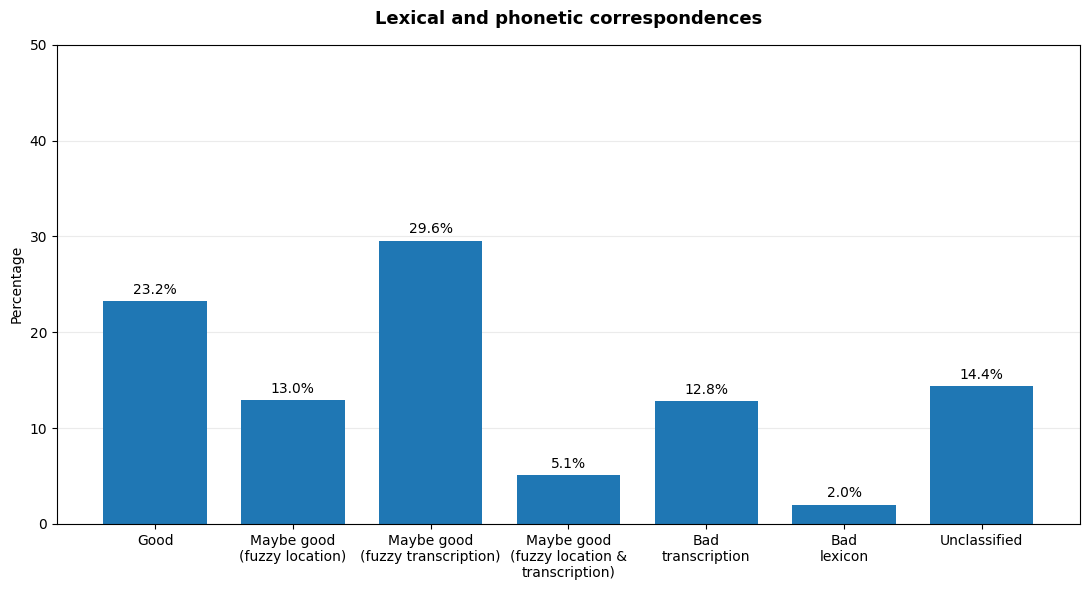

In [7]:

# GRAPHIQUE

labels = [
    "Good",
    "Maybe good\n(fuzzy location)",
    "Maybe good\n(fuzzy transcription)",
    "Maybe good\n(fuzzy location &\ntranscription)",
    "Bad\ntranscription",
    "Bad\nlexicon",
    "Unclassified",
]

values = proportions.values

visible = values > 0

plot_labels = [label for label, keep in zip(labels, visible) if keep]
plot_values = values[visible]

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(
    range(len(plot_values)),
    plot_values,
    width=0.75,
)

for bar, value in zip(bars, plot_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + max(plot_values) * 0.015,
        f"{value:.{DECIMALS}f}%",
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_xticks(range(len(plot_values)))
ax.set_xticklabels(plot_labels, fontsize=10)

ax.set_ylabel("Percentage")
ax.set_xlabel("")

ax.set_ylim(0, max(50, max(plot_values) * 1.18))

ax.grid(
    axis="y",
    linestyle="-",
    alpha=0.25,
)

ax.set_axisbelow(True)

ax.set_title(
    TITLE,
    fontsize=13,
    fontweight="bold",
    pad=15,
)

plt.tight_layout()

plt.savefig(
    OUTPUT_PNG,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

